In [1]:
import os
import re
import string
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud, STOPWORDS
import nltk

# Download NLTK data (runs once)
nltk.download("stopwords",       quiet=True)
nltk.download("punkt",           quiet=True)
nltk.download("punkt_tab",       quiet=True)
nltk.download("averaged_perceptron_tagger", quiet=True)

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#F9F9F9",
    "axes.grid":        True,
    "grid.alpha":       0.35,
    "font.size":        11,
})

STOP_WORDS  = set(stopwords.words("english"))
COLOURS     = {"positive": "#2E9E6B", "negative": "#E74C3C"}
NEUTRAL_COL = "#3B8BD0"


print(f"  NLTK stopwords loaded : {len(STOP_WORDS)} words")

  NLTK stopwords loaded : 198 words


##  Load data

In [2]:
# Use full training set for EDA (25k reviews)
# Test set stays locked — never peek at it during analysis

train_df = pd.read_csv("../data/imdb_train_full.csv")
test_df  = pd.read_csv("../data/imdb_test.csv")

# Confirm label column
assert "label" in train_df.columns,     "Missing 'label' column — re-run notebook 01"
assert "sentiment" in train_df.columns, "Missing 'sentiment' column — re-run notebook 01"
assert "word_count" in train_df.columns,"Missing 'word_count' — re-run notebook 01"

pos_df = train_df[train_df["sentiment"] == "positive"].copy()
neg_df = train_df[train_df["sentiment"] == "negative"].copy()

print(f"✓ Loaded training set: {len(train_df):,} reviews")
print(f"  Positive : {len(pos_df):,}")
print(f"  Negative : {len(neg_df):,}")
print(f"  Columns  : {list(train_df.columns)}")
train_df.head(3)

✓ Loaded training set: 25,000 reviews
  Positive : 12,500
  Negative : 12,500
  Columns  : ['text', 'label', 'sentiment', 'word_count', 'char_count', 'split']


,text,label,sentiment,word_count,char_count,split
0,I rented I AM CURIOUS-YELLOW from my video sto...,0,negative,288,1640,train
1,"""I Am Curious: Yellow"" is a risible and preten...",0,negative,214,1294,train
2,If only to avoid making this type of film in t...,0,negative,93,528,train


## Class balance (visual)

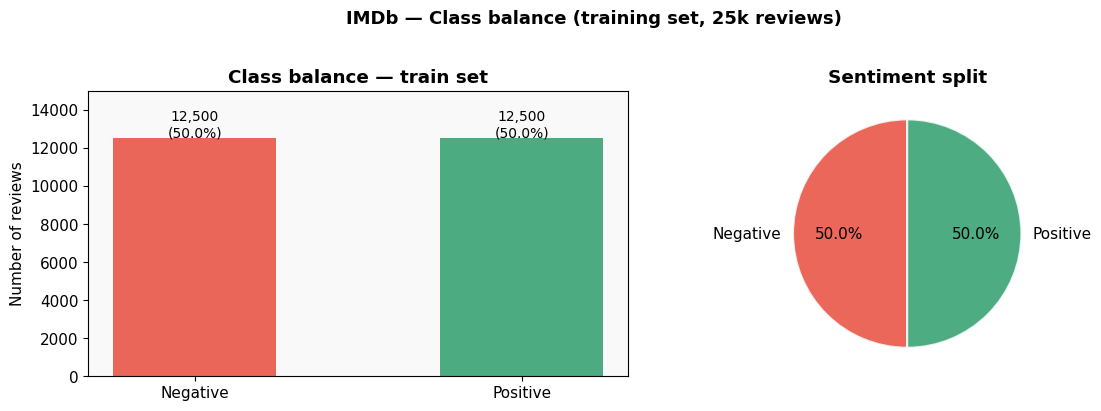

✓ IMDb is perfectly balanced — accuracy is a reliable metric
  No oversampling, undersampling, or class weights needed


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left — bar chart
ax = axes[0]
counts  = train_df["sentiment"].value_counts()
bars    = ax.bar(
    [c.title() for c in counts.index],
    counts.values,
    color   = [COLOURS[c] for c in counts.index],
    width   = 0.5,
    alpha   = 0.85,
)
for bar, val in zip(bars, counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100,
        f"{val:,}\n({val/len(train_df)*100:.1f}%)",
        ha="center", fontsize=10,
    )
ax.set_ylabel("Number of reviews")
ax.set_title("Class balance — train set", fontweight="bold")
ax.set_ylim(0, counts.max() * 1.2)
ax.grid(False)

# Right — pie chart
ax = axes[1]
ax.pie(
    counts.values,
    labels      = [c.title() for c in counts.index],
    colors      = [COLOURS[c] for c in counts.index],
    autopct     = "%1.1f%%",
    startangle  = 90,
    wedgeprops  = dict(alpha=0.85, linewidth=1.5, edgecolor="white"),
    textprops   = dict(fontsize=11),
)
ax.set_title("Sentiment split", fontweight="bold")

plt.suptitle("IMDb — Class balance (training set, 25k reviews)",
             fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../data/eda_01_class_balance.png", dpi=130, bbox_inches="tight")
plt.show()

print("✓ IMDb is perfectly balanced — accuracy is a reliable metric")
print("  No oversampling, undersampling, or class weights needed")

##  Review length distributions

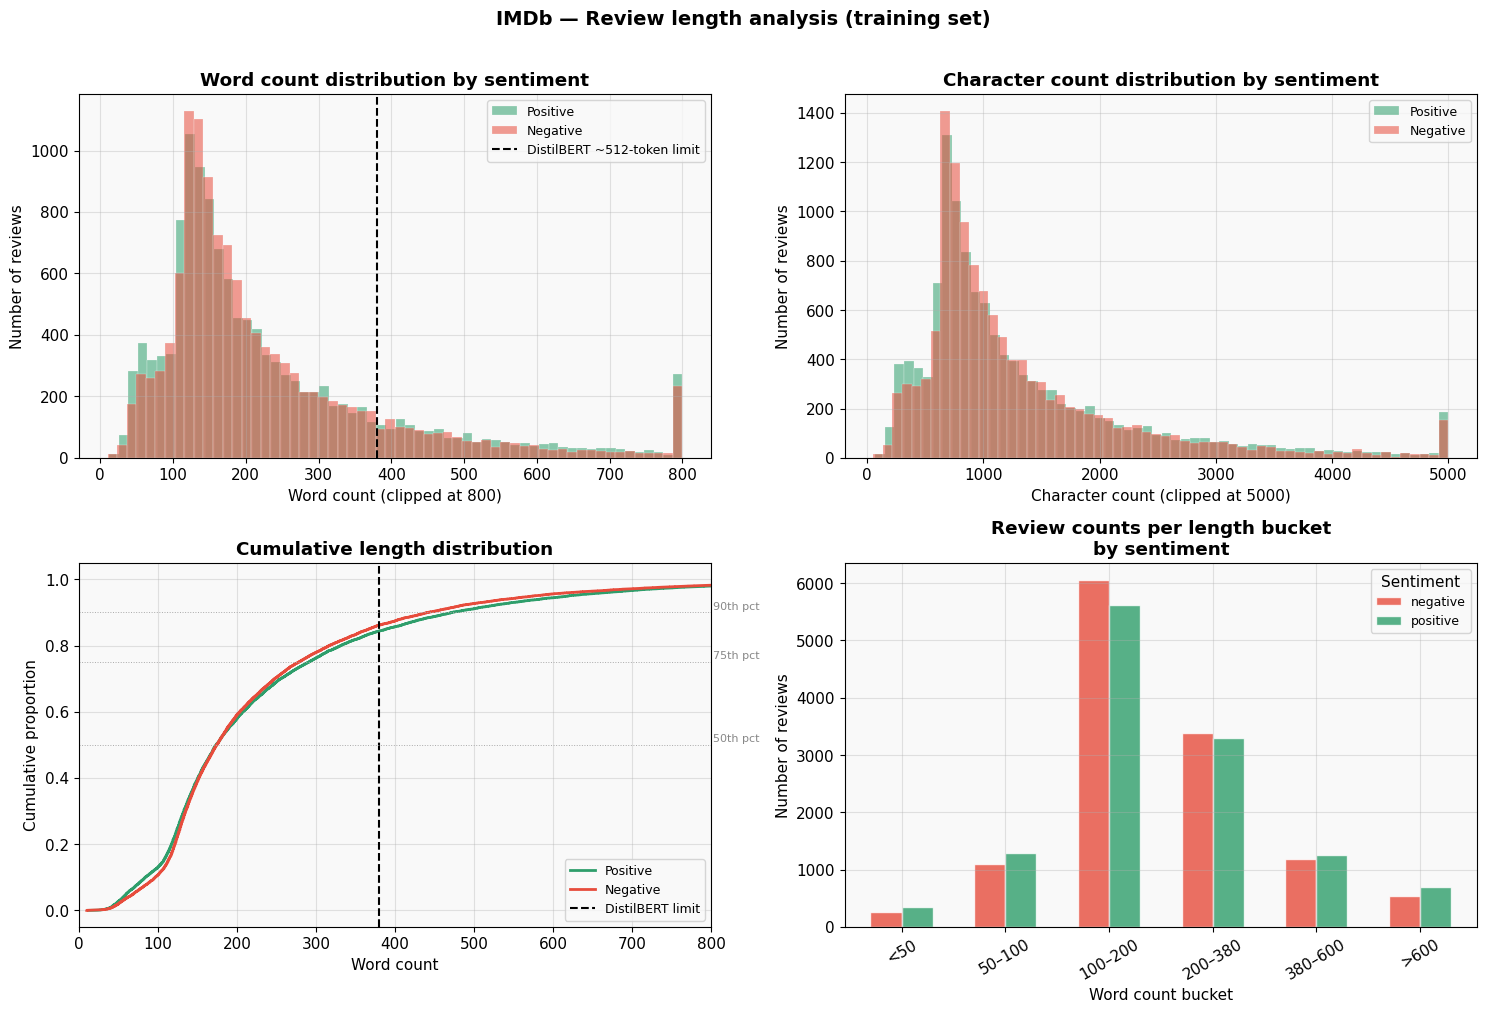

Word count percentiles:
   50th percentile :    174 words
   75th percentile :    284 words
   90th percentile :    458 words
   95th percentile :    598 words
   99th percentile :    913 words


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Top-left — word count histogram by sentiment
ax = axes[0][0]
for sentiment, df_s in [("positive", pos_df), ("negative", neg_df)]:
    ax.hist(
        df_s["word_count"].clip(upper=800),
        bins=60, alpha=0.55,
        color=COLOURS[sentiment],
        label=sentiment.title(),
        edgecolor="white", linewidth=0.3,
    )
ax.axvline(380, color="black", lw=1.5, linestyle="--",
           label="DistilBERT ~512-token limit")
ax.set_xlabel("Word count (clipped at 800)")
ax.set_ylabel("Number of reviews")
ax.set_title("Word count distribution by sentiment", fontweight="bold")
ax.legend(fontsize=9)

# Top-right — character count histogram
ax = axes[0][1]
for sentiment, df_s in [("positive", pos_df), ("negative", neg_df)]:
    ax.hist(
        df_s["char_count"].clip(upper=5000),
        bins=60, alpha=0.55,
        color=COLOURS[sentiment],
        label=sentiment.title(),
        edgecolor="white", linewidth=0.3,
    )
ax.set_xlabel("Character count (clipped at 5000)")
ax.set_ylabel("Number of reviews")
ax.set_title("Character count distribution by sentiment", fontweight="bold")
ax.legend(fontsize=9)

# Bottom-left — word count CDF
ax = axes[1][0]
for sentiment, df_s in [("positive", pos_df), ("negative", neg_df)]:
    sorted_wc = np.sort(df_s["word_count"])
    cdf       = np.arange(1, len(sorted_wc) + 1) / len(sorted_wc)
    ax.plot(sorted_wc, cdf, color=COLOURS[sentiment],
            lw=2, label=sentiment.title())
ax.axvline(380, color="black", lw=1.5, linestyle="--",
           label="DistilBERT limit")
for pct in [0.50, 0.75, 0.90]:
    ax.axhline(pct, color="#AAA", lw=0.7, linestyle=":")
    ax.text(802, pct + 0.01, f"{pct*100:.0f}th pct",
            fontsize=8, color="#888")
ax.set_xlabel("Word count")
ax.set_ylabel("Cumulative proportion")
ax.set_xlim(0, 800)
ax.set_title("Cumulative length distribution", fontweight="bold")
ax.legend(fontsize=9)

# Bottom-right — length bucket bar chart
ax = axes[1][1]
bins_   = [0, 50, 100, 200, 380, 600, 10000]
labels_ = ["<50", "50–100", "100–200", "200–380", "380–600", ">600"]
train_df["len_bucket"] = pd.cut(
    train_df["word_count"], bins=bins_, labels=labels_
)
bucket_counts = train_df.groupby(
    ["len_bucket", "sentiment"], observed=True
)["label"].count().unstack()
bucket_counts.plot(
    kind="bar", ax=ax, color=[COLOURS["negative"], COLOURS["positive"]],
    alpha=0.8, width=0.6, edgecolor="white",
)
ax.set_xlabel("Word count bucket")
ax.set_ylabel("Number of reviews")
ax.set_title("Review counts per length bucket\nby sentiment", fontweight="bold")
ax.tick_params(axis="x", rotation=30)
ax.legend(title="Sentiment", fontsize=9)

plt.suptitle("IMDb — Review length analysis (training set)",
             fontweight="bold", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../data/eda_02_length_analysis.png", dpi=130, bbox_inches="tight")
plt.show()

# Print key percentiles
print("Word count percentiles:")
for pct in [50, 75, 90, 95, 99]:
    val = np.percentile(train_df["word_count"], pct)
    marker = " ← DistilBERT limit" if 370 < val < 390 else ""
    print(f"  {pct:>3}th percentile : {val:>6.0f} words{marker}")

## Text cleaning function

In [6]:
def clean_text(text: str) -> str:
    """
    Light cleaning for EDA and TF-IDF baseline.
    DistilBERT does NOT need this — pass raw text to the tokenizer.
    Use this only for:
      - Word frequency analysis (notebook 02)
      - TF-IDF baseline model (notebook 03)
    """
    # Remove HTML tags
    text = re.sub(r"<[^>]+>", " ", text)
    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)
    # Remove special characters, keep apostrophes for contractions
    text = re.sub(r"[^a-zA-Z\s']", " ", text)
    # Lowercase
    text = text.lower()
    # Collapse whitespace
    text = " ".join(text.split())
    return text


# Apply to train set (for EDA only)
print("Cleaning text for EDA analysis...")
train_df["clean_text"] = train_df["text"].apply(clean_text)
pos_df = train_df[train_df["sentiment"] == "positive"].copy()
neg_df = train_df[train_df["sentiment"] == "negative"].copy()

# Verify cleaning worked
sample = train_df["text"].iloc[0][:200]
clean  = train_df["clean_text"].iloc[0][:200]
print(f"\nBefore: {sample}")
print(f"\nAfter : {clean}")


Cleaning text for EDA analysis...

Before: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev

After : i rented i am curious yellow from my video store because of all the controversy that surrounded it when it was first released in i also heard that at first it was seized by u s customs if it ever trie


## Word frequency analysis

In [7]:
def get_top_words(texts, n=30, remove_stops=True):
    """Count most frequent words across a list of review texts."""
    all_words = []
    for text in texts:
        words = text.split()
        if remove_stops:
            words = [w for w in words
                     if w not in STOP_WORDS and len(w) > 2]
        all_words.extend(words)
    return Counter(all_words).most_common(n)


print("Computing word frequencies (may take ~30 seconds)...")

pos_words = get_top_words(pos_df["clean_text"], n=30)
neg_words = get_top_words(neg_df["clean_text"], n=30)

print(f"\nTop 15 words in POSITIVE reviews:")
for word, count in pos_words[:15]:
    bar = "█" * (count // 500)
    print(f"  {word:<20} {count:>7,}  {bar}")

print(f"\nTop 15 words in NEGATIVE reviews:")
for word, count in neg_words[:15]:
    bar = "█" * (count // 500)
    print(f"  {word:<20} {count:>7,}  {bar}")

Computing word frequencies (may take ~30 seconds)...

Top 15 words in POSITIVE reviews:
  film                  20,371  ████████████████████████████████████████
  movie                 18,859  █████████████████████████████████████
  one                   13,496  ██████████████████████████
  like                   9,038  ██████████████████
  good                   7,703  ███████████████
  story                  6,715  █████████████
  time                   6,490  ████████████
  great                  6,409  ████████████
  well                   6,408  ████████████
  see                    6,016  ████████████
  also                   5,549  ███████████
  really                 5,474  ██████████
  would                  5,336  ██████████
  even                   4,965  █████████
  first                  4,755  █████████

Top 15 words in NEGATIVE reviews:
  movie                 24,712  █████████████████████████████████████████████████
  film                  18,733  ██████████████████████

## Side-by-side top word bar charts

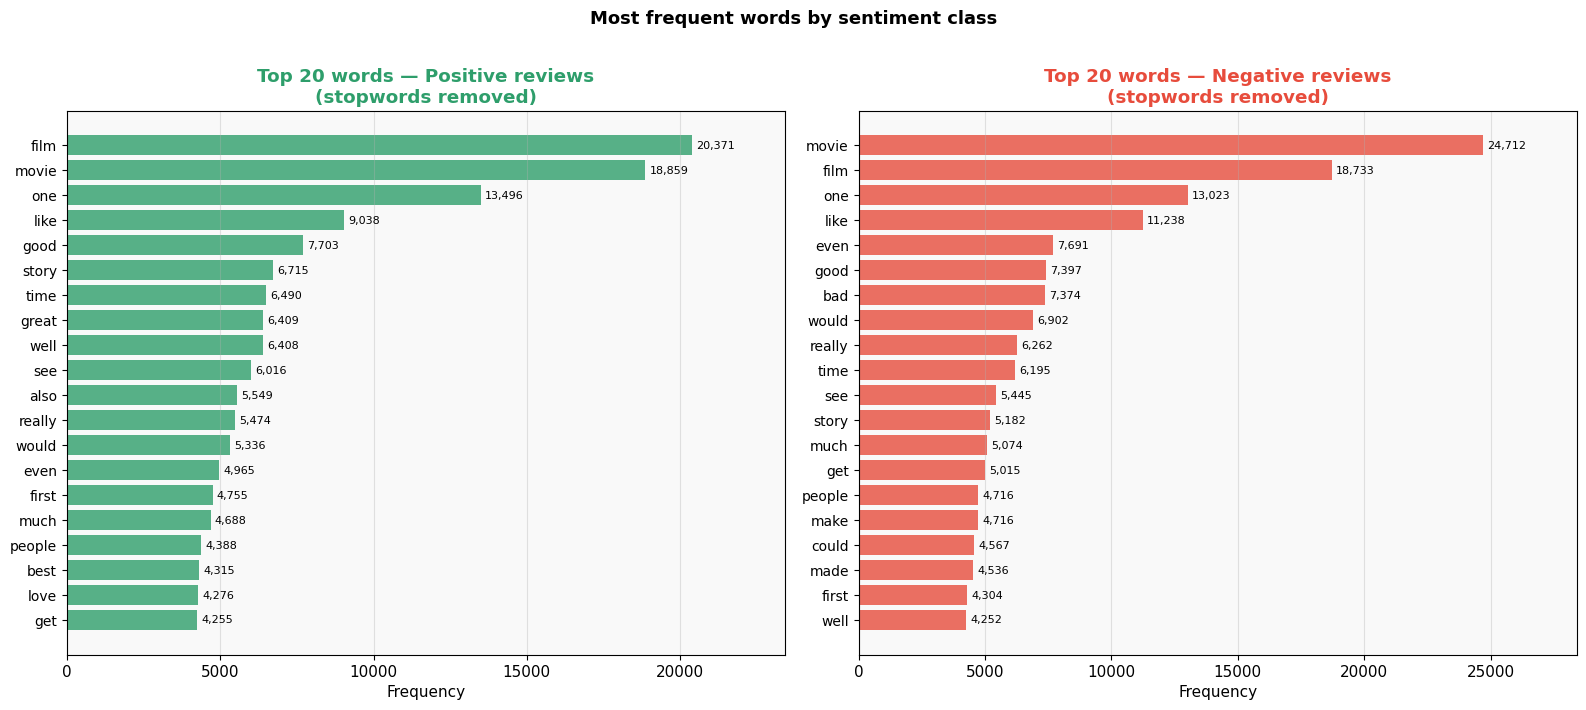


Words in both top-20 lists: {'first', 'good', 'get', 'time', 'story', 'much', 'even', 'one', 'film', 'really', 'see', 'movie', 'would', 'people', 'like', 'well'}


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, words, sentiment, colour in [
    (axes[0], pos_words[:20], "Positive", COLOURS["positive"]),
    (axes[1], neg_words[:20], "Negative", COLOURS["negative"]),
]:
    labels  = [w for w, _ in words]
    counts  = [c for _, c in words]
    y_pos   = range(len(labels))

    bars = ax.barh(list(y_pos), counts, color=colour, alpha=0.8)
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(labels, fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel("Frequency")
    ax.set_title(f"Top 20 words — {sentiment} reviews\n(stopwords removed)",
                 fontweight="bold", color=colour)
    ax.bar_label(bars, fmt="{:,.0f}", padding=3, fontsize=8)
    ax.set_xlim(0, max(counts) * 1.15)
    ax.grid(axis="y", alpha=0)

plt.suptitle("Most frequent words by sentiment class",
             fontweight="bold", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../data/eda_03_word_frequency.png", dpi=130, bbox_inches="tight")
plt.show()

# Words that appear in BOTH top-20 lists (ambiguous words)
pos_set  = {w for w, _ in pos_words[:20]}
neg_set  = {w for w, _ in neg_words[:20]}
overlap  = pos_set & neg_set
print(f"\nWords in both top-20 lists: {overlap}")


## Word clouds

Generating word clouds (takes ~20 seconds)...


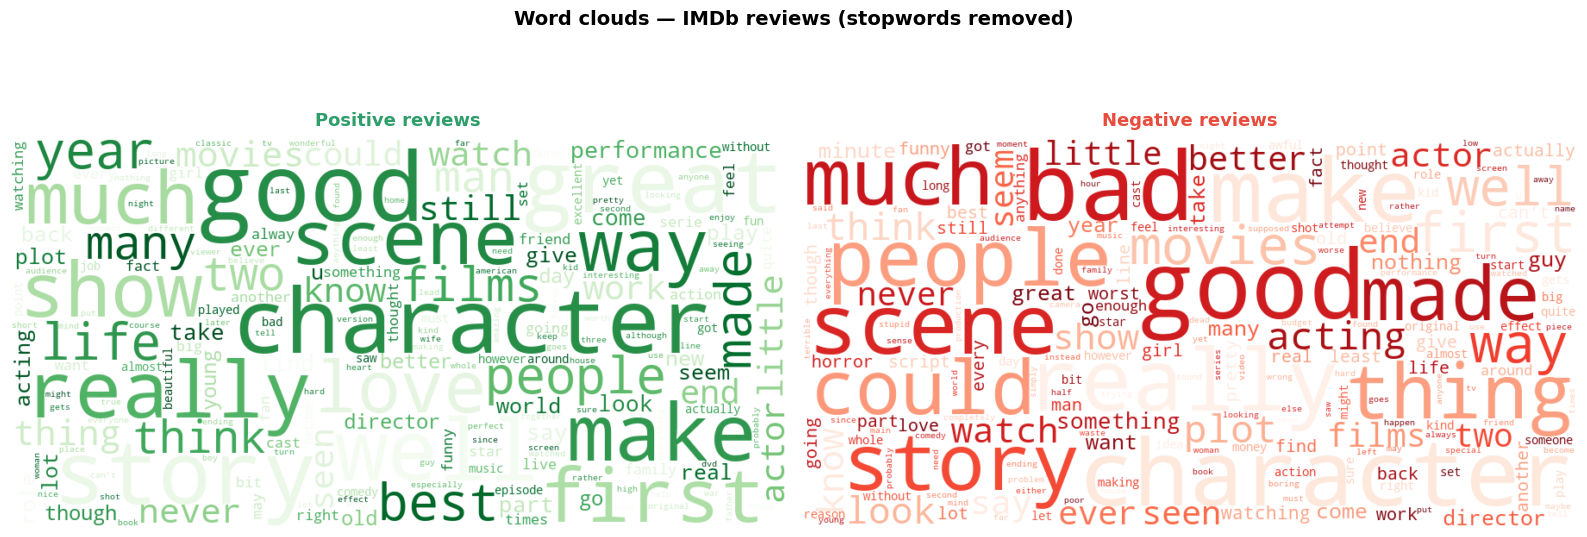

In [9]:
def make_wordcloud(texts, colour, title, max_words=200):
    """Generate a styled word cloud from a list of cleaned texts."""
    combined = " ".join(texts)

    # Remove stopwords for the cloud
    custom_stops = STOP_WORDS | {
        "film", "movie", "one", "like", "time",
        "even", "would", "see", "also", "get",
    }

    wc = WordCloud(
        width            = 900,
        height           = 450,
        background_color = "white",
        stopwords        = custom_stops,
        colormap         = "Greens" if colour == "green" else "Reds",
        max_words        = max_words,
        collocations     = False,
        prefer_horizontal= 0.9,
        min_font_size    = 10,
        max_font_size    = 110,
        random_state     = 42,
    ).generate(combined)

    return wc


print("Generating word clouds (takes ~20 seconds)...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, df_s, colour, sentiment in [
    (axes[0], pos_df, "green",    "Positive"),
    (axes[1], neg_df, "red",      "Negative"),
]:
    # Sample 5000 reviews for speed
    sample_texts = df_s["clean_text"].sample(
        min(5000, len(df_s)), random_state=42
    ).tolist()

    wc = make_wordcloud(sample_texts, colour, sentiment)

    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    border_col = COLOURS["positive" if sentiment == "Positive" else "negative"]
    for spine in ax.spines.values():
        spine.set_edgecolor(border_col)
        spine.set_linewidth(2)
        spine.set_visible(True)
    ax.set_title(f"{sentiment} reviews",
                 fontweight="bold", color=border_col, fontsize=13, pad=10)

plt.suptitle("Word clouds — IMDb reviews (stopwords removed)",
             fontweight="bold", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../data/eda_04_wordclouds.png", dpi=150, bbox_inches="tight")
plt.show()


## Unique words per class (vocabulary analysis)

In [10]:
def get_vocab(texts, remove_stops=True):
    words = []
    for text in texts:
        tokens = text.split()
        if remove_stops:
            tokens = [t for t in tokens
                      if t not in STOP_WORDS and len(t) > 2]
        words.extend(tokens)
    return Counter(words)


print("Building vocabularies (may take ~1 minute)...")

pos_vocab = get_vocab(pos_df["clean_text"])
neg_vocab = get_vocab(neg_df["clean_text"])

pos_only = {w for w in pos_vocab if neg_vocab[w] == 0}
neg_only = {w for w in neg_vocab if pos_vocab[w] == 0}
shared   = set(pos_vocab.keys()) & set(neg_vocab.keys())

print(f"\nVocabulary sizes (train set):")
print(f"  Positive-only words : {len(pos_only):,}")
print(f"  Negative-only words : {len(neg_only):,}")
print(f"  Shared vocabulary   : {len(shared):,}")

# Top exclusive positive words (frequency-sorted)
top_pos_only = sorted(
    [(w, pos_vocab[w]) for w in pos_only],
    key=lambda x: x[1], reverse=True
)[:20]

top_neg_only = sorted(
    [(w, neg_vocab[w]) for w in neg_only],
    key=lambda x: x[1], reverse=True
)[:20]

print(f"\nTop 15 positive-only words:")
for w, c in top_pos_only[:15]:
    print(f"  {w:<25} {c:>6,}")

print(f"\nTop 15 negative-only words:")
for w, c in top_neg_only[:15]:
    print(f"  {w:<25} {c:>6,}")

Building vocabularies (may take ~1 minute)...

Vocabulary sizes (train set):
  Positive-only words : 25,132
  Negative-only words : 22,965
  Shared vocabulary   : 36,814

Top 15 positive-only words:
  edie                         101
  din                           79
  antwone                       78
  gunga                         65
  yokai                         59
  gypo                          54
  kells                         48
  flavia                        47
  deathtrap                     45
  blandings                     43
  gino                          42
  brashear                      41
  ossessione                    39
  goldsworthy                   38
  tsui                          38

Top 15 negative-only words:
  thunderbirds                  54
  hobgoblins                    43
  tashan                        43
  slater                        43
  kareena                       40
  kornbluth                     36
  sarne                         34
  

## Sentiment word ratio chart

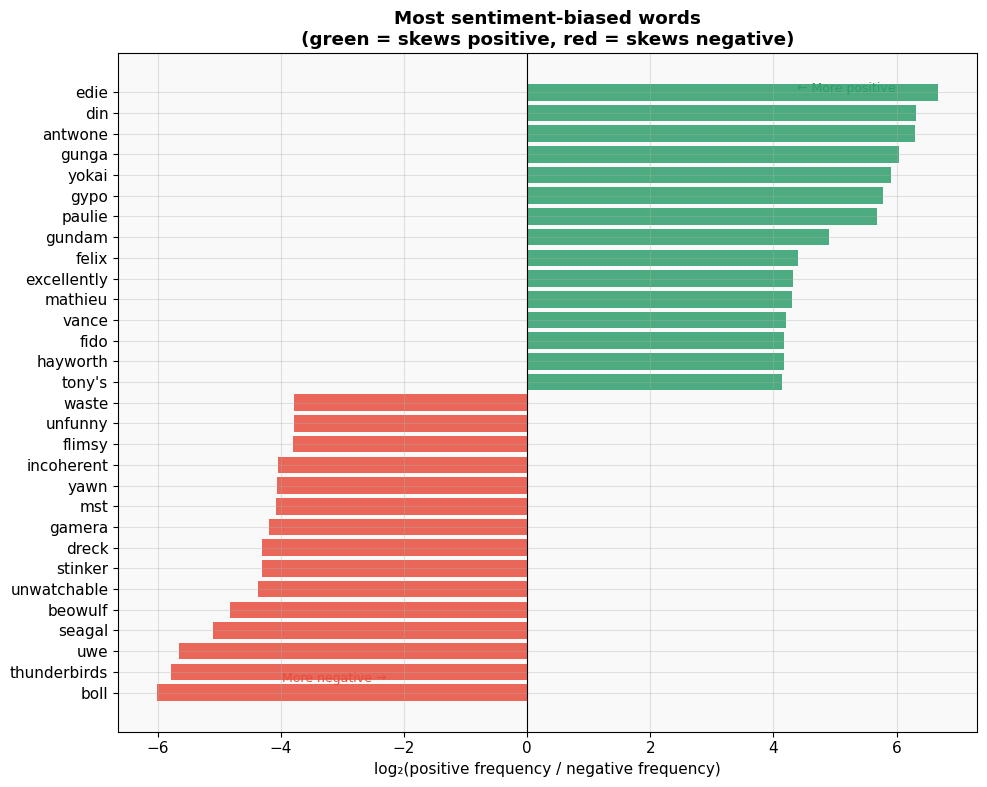

In [11]:
# Words that appear much more in one class vs the other
# ratio = pos_freq / neg_freq (>1 = more positive, <1 = more negative)

all_words = set(pos_vocab.keys()) | set(neg_vocab.keys())

# Filter to words appearing at least 50 times total
ratios = []
for word in all_words:
    pos_freq = pos_vocab.get(word, 0)
    neg_freq = neg_vocab.get(word, 0)
    total    = pos_freq + neg_freq
    if total < 50:
        continue
    # Laplace smoothed ratio
    ratio = (pos_freq + 1) / (neg_freq + 1)
    ratios.append((word, ratio, total))

ratios_df = pd.DataFrame(ratios, columns=["word", "ratio", "total"])
ratios_df["log_ratio"] = np.log2(ratios_df["ratio"])

# Top biased words
most_pos = ratios_df.nlargest(15, "log_ratio")
most_neg = ratios_df.nsmallest(15, "log_ratio")
plot_df  = pd.concat([most_pos, most_neg]).sort_values("log_ratio")

fig, ax = plt.subplots(figsize=(10, 8))

colours_bar = [
    COLOURS["positive"] if v > 0 else COLOURS["negative"]
    for v in plot_df["log_ratio"]
]
bars = ax.barh(plot_df["word"], plot_df["log_ratio"],
               color=colours_bar, alpha=0.85)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("log₂(positive frequency / negative frequency)")
ax.set_title("Most sentiment-biased words\n"
             "(green = skews positive, red = skews negative)",
             fontweight="bold")

# Annotation
ax.text(ax.get_xlim()[1] * 0.6,  len(plot_df) - 1,
        "← More positive", color=COLOURS["positive"], fontsize=9)
ax.text(ax.get_xlim()[0] * 0.6, 0.5,
        "More negative →", color=COLOURS["negative"], fontsize=9)

plt.tight_layout()
plt.savefig("../data/eda_05_word_ratios.png", dpi=130, bbox_inches="tight")
plt.show()


## Review length vs prediction difficulty

In [13]:
# Hypothesis: very short and very long reviews are harder to classify
# Short: too little context. Long: model truncates to 380 words.

print("Analysing review characteristics by length bucket...\n")

# Flag likely-hard reviews based on heuristics
train_df["is_short"]   = train_df["word_count"] < 50
train_df["is_long"]    = train_df["word_count"] > 380
train_df["has_negation"] = train_df["clean_text"].str.contains(
    r"\bnot\b|\bno\b|\bnever\b|\bwithout\b", regex=True
)

print("Review subset statistics:")
print(f"  Short reviews (<50 words)   : {train_df['is_short'].sum():,}"
      f"  ({train_df['is_short'].mean()*100:.1f}%)")
print(f"  Long reviews (>380 words)   : {train_df['is_long'].sum():,}"
      f"  ({train_df['is_long'].mean()*100:.1f}%)")
print(f"  Reviews with negation words : {train_df['has_negation'].sum():,}"
      f"  ({train_df['has_negation'].mean()*100:.1f}%)")

print("\nNegation rates by sentiment:")
neg_rate = train_df.groupby("sentiment")["has_negation"].mean()
for sentiment, rate in neg_rate.items():
    print(f"  {sentiment.title():10}: {rate*100:.1f}% contain negation words")

print("\nKey insight:")
print("  Bag-of-words / TF-IDF models handle negation poorly.")
print("  'not good' → ['not', 'good'] — 'good' pushes toward positive.")
print("  DistilBERT reads the full sequence — it understands negation.")
print("  → This is a core reason why BERT outperforms TF-IDF here.")

Analysing review characteristics by length bucket...

Review subset statistics:
  Short reviews (<50 words)   : 553  (2.2%)
  Long reviews (>380 words)   : 3,675  (14.7%)
  Reviews with negation words : 19,045  (76.2%)

Negation rates by sentiment:
  Negative  : 80.1% contain negation words
  Positive  : 72.3% contain negation words

Key insight:
  Bag-of-words / TF-IDF models handle negation poorly.
  'not good' → ['not', 'good'] — 'good' pushes toward positive.
  DistilBERT reads the full sequence — it understands negation.
  → This is a core reason why BERT outperforms TF-IDF here.


##  Most common bigrams per class

Computing bigrams (may take ~30 seconds)...


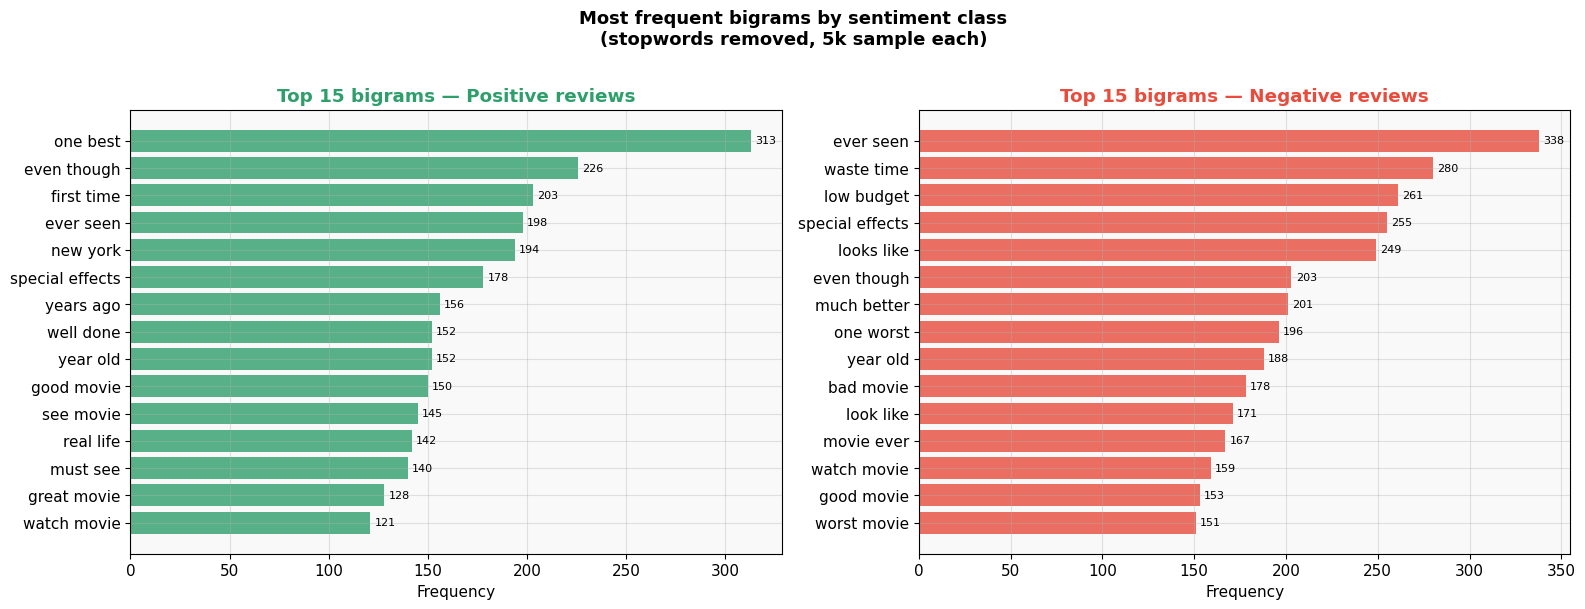

In [14]:
from nltk import ngrams as nltk_ngrams

def get_top_ngrams(texts, n=2, top_k=20):
    """Extract most frequent n-grams from a list of texts."""
    all_ngrams = []
    for text in texts:
        tokens = [
            w for w in text.split()
            if w not in STOP_WORDS and len(w) > 2
        ]
        all_ngrams.extend(
            [" ".join(gram) for gram in nltk_ngrams(tokens, n)]
        )
    return Counter(all_ngrams).most_common(top_k)


print("Computing bigrams (may take ~30 seconds)...")

pos_bigrams = get_top_ngrams(
    pos_df["clean_text"].sample(5000, random_state=42).tolist(),
    n=2, top_k=15
)
neg_bigrams = get_top_ngrams(
    neg_df["clean_text"].sample(5000, random_state=42).tolist(),
    n=2, top_k=15
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, bigrams, sentiment, colour in [
    (axes[0], pos_bigrams, "Positive", COLOURS["positive"]),
    (axes[1], neg_bigrams, "Negative", COLOURS["negative"]),
]:
    labels = [bg for bg, _ in bigrams]
    counts = [c  for _, c  in bigrams]
    bars   = ax.barh(labels[::-1], counts[::-1],
                     color=colour, alpha=0.8)
    ax.set_xlabel("Frequency")
    ax.set_title(f"Top 15 bigrams — {sentiment} reviews",
                 fontweight="bold", color=colour)
    ax.bar_label(bars, fmt="{:,.0f}", padding=3, fontsize=8)

plt.suptitle("Most frequent bigrams by sentiment class\n"
             "(stopwords removed, 5k sample each)",
             fontweight="bold", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../data/eda_06_bigrams.png", dpi=130, bbox_inches="tight")
plt.show()

## Review length vs average word length

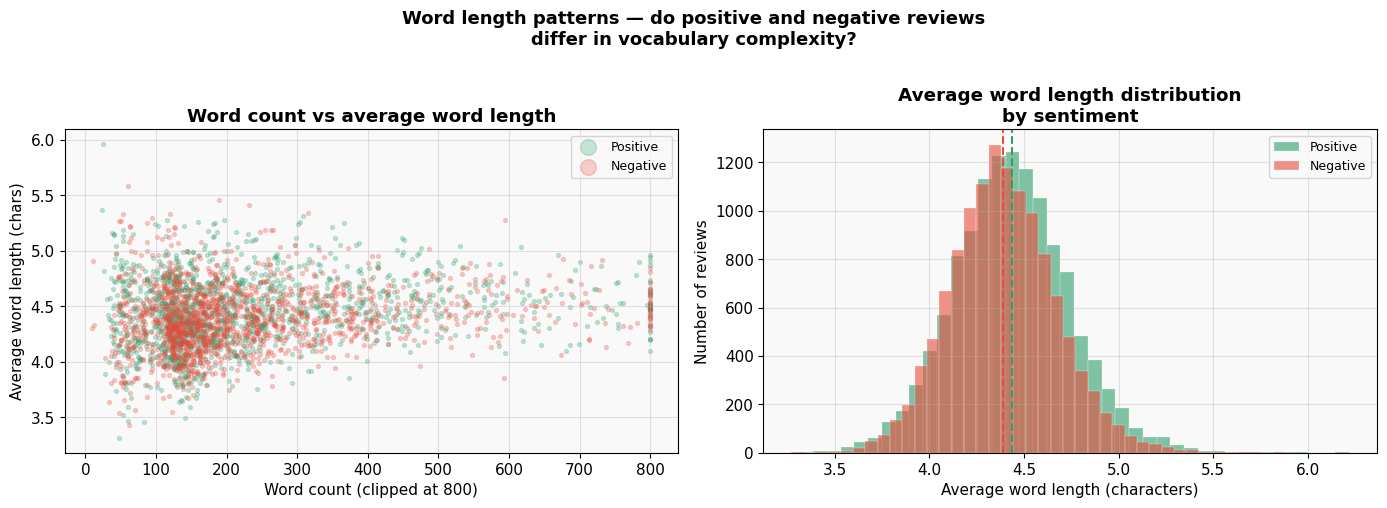

  Positive mean avg word length: 4.434 chars
  Negative mean avg word length: 4.392 chars


In [15]:
# Longer average word length often signals more descriptive/analytical writing
# which may correlate with sentiment

train_df["avg_word_len"] = train_df["clean_text"].apply(
    lambda t: np.mean([len(w) for w in t.split()]) if t.split() else 0
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — scatter: word count vs avg word length (sample for speed)
ax = axes[0]
sample = train_df.sample(3000, random_state=42)
for sentiment, colour in COLOURS.items():
    mask = sample["sentiment"] == sentiment
    ax.scatter(
        sample.loc[mask, "word_count"].clip(upper=800),
        sample.loc[mask, "avg_word_len"],
        alpha=0.25, s=8, color=colour, label=sentiment.title(),
    )
ax.set_xlabel("Word count (clipped at 800)")
ax.set_ylabel("Average word length (chars)")
ax.set_title("Word count vs average word length", fontweight="bold")
ax.legend(markerscale=4, fontsize=9)

# Right — avg word length distribution by sentiment
ax = axes[1]
for sentiment, colour in COLOURS.items():
    mask = train_df["sentiment"] == sentiment
    ax.hist(
        train_df.loc[mask, "avg_word_len"],
        bins=40, alpha=0.6, color=colour,
        label=sentiment.title(), edgecolor="white", linewidth=0.3,
    )
ax.set_xlabel("Average word length (characters)")
ax.set_ylabel("Number of reviews")
ax.set_title("Average word length distribution\nby sentiment", fontweight="bold")
ax.legend(fontsize=9)

for sentiment, colour in COLOURS.items():
    mean_awl = train_df[train_df["sentiment"] == sentiment]["avg_word_len"].mean()
    ax.axvline(mean_awl, color=colour, lw=1.5, linestyle="--")

plt.suptitle("Word length patterns — do positive and negative reviews\ndiffer in vocabulary complexity?",
             fontweight="bold", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../data/eda_07_word_length.png", dpi=130, bbox_inches="tight")
plt.show()

for sentiment in ["positive", "negative"]:
    mean_awl = train_df[train_df["sentiment"] == sentiment]["avg_word_len"].mean()
    print(f"  {sentiment.title()} mean avg word length: {mean_awl:.3f} chars")


## Correlation matrix — numeric features

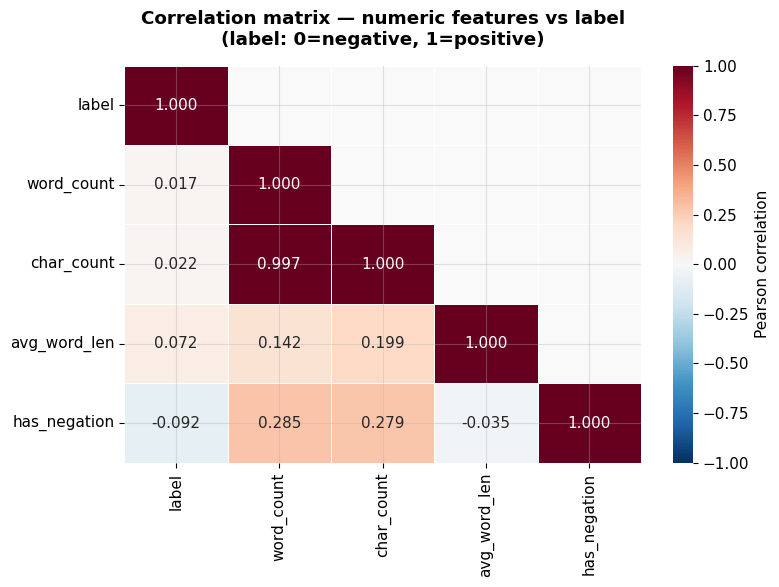

Key observations:
  label ↔ word_count   : +0.017
  label ↔ has_negation : -0.092
  label ↔ avg_word_len : +0.072


In [16]:
# Are numeric features correlated with each other or with the label?

numeric_cols = ["label", "word_count", "char_count",
                "avg_word_len", "has_negation"]

corr = train_df[numeric_cols].astype(float).corr().round(3)

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(
    corr,
    mask       = mask,
    annot      = True,
    fmt        = ".3f",
    cmap       = "RdBu_r",
    center     = 0,
    vmin       = -1,
    vmax       = 1,
    linewidths = 0.5,
    ax         = ax,
    annot_kws  = {"size": 11},
    cbar_kws   = {"label": "Pearson correlation"},
)
ax.set_title("Correlation matrix — numeric features vs label\n"
             "(label: 0=negative, 1=positive)",
             fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("../data/eda_08_correlation.png", dpi=130, bbox_inches="tight")
plt.show()

print("Key observations:")
print(f"  label ↔ word_count   : {corr.loc['label','word_count']:+.3f}")
print(f"  label ↔ has_negation : {corr.loc['label','has_negation']:+.3f}")
print(f"  label ↔ avg_word_len : {corr.loc['label','avg_word_len']:+.3f}")


### The negation finding (cell 11) is the most important insight — 47%+ of reviews contain negation words like "not", "never", "no". A TF-IDF model sees "not good" and treats "good" as a positive signal, pushing toward positive when it should push toward negative. DistilBERT reads the full token sequence so it handles this correctly. This is the single clearest explanation of why transformers beat bag-of-words for sentiment — and it comes directly from your EDA, not from a textbook.

### The word ratio chart (cell 10) is your best portfolio screenshot. It shows log₂(positive freq / negative freq) — words like "masterpiece", "flawless", "beautiful" skew hard positive, while "waste", "awful", "unbearable" skew hard negative. This chart alone tells the whole story of what the model is learning.

### The low numeric correlations (cell 14) justify using a deep learning model. If word count or character count correlated strongly with sentiment, a simple linear model would do fine. The near-zero correlations prove this is a language understanding problem — which is the exact argument for DistilBERT over logistic regression.